# 04 — Auto-annotation: SAM 3 zero-shot → COCO → Roboflow

**Objetivo:** generar dataset balanceado de ~1000 frames anotados automáticamente por SAM 3 (zero-shot) con 3 clases — `robot`, `orange_ball`, `green_floor` — exportar a COCO y opcionalmente subir a Roboflow vía SDK.

**Sampling (Opción A):** 8 frames evenly spaced de cada uno de los 123 videos → ~984 frames totales.

**Output local:**
```
outputs/coco_dataset_v1/
├── images/
│   ├── frame_00000.jpg
│   └── ... (~1000 frames)
└── annotations.json   # COCO instance segmentation
```

**Tiempo estimado:**
- CPU pod (8 vCPU, 16 GB): ~10 s × 3 prompts × N_FRAMES → **~50 min para 100, ~8 hrs para 1000**
- GPU 5090: ~0.5 s × 3 × N_FRAMES → **~3 min para 100, ~25 min para 1000**

**Recomendación:** correr `N_FRAMES = 50` en CPU primero para validar pipeline; después prender 5090 y subir a `N_FRAMES = 1000`.

## 1. Config (edita aquí)

In [1]:
# Tamaño del dataset a generar
TARGET_FRAMES = 100  # Re-test v2 con PNG + kernels + filename trazable

# Roboflow project info
ROBOFLOW_WORKSPACE = 'futbot2026segmentation'
ROBOFLOW_PROJECT   = 'segmentacion_futbot-kwqqr'
ROBOFLOW_UPLOAD    = True

# Folder name: outputs/<DATASET_VERSION>/{images, labels}
DATASET_VERSION = '100_v2_images_labels'

# Image format (png = lossless, jpg = smaller)
IMG_FORMAT = 'png'  # 'png' o 'jpg'


## 2. Imports + load env

In [2]:
import os, sys, json, time
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple
from collections import Counter

import numpy as np
import torch
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import decord
from tqdm.auto import tqdm
from transformers import AutoProcessor, AutoModel

# Carga env (HF_TOKEN, ROBOFLOW_API_KEY)
env_file = Path('/workspace/.env')
if env_file.exists():
    for line in env_file.read_text().splitlines():
        if '=' in line and not line.startswith('#'):
            k, v = line.split('=', 1)
            os.environ.setdefault(k.strip(), v.strip())

WORKSPACE = Path('/workspace')
REPO      = WORKSPACE / 'FutBotMX-UAQTeam'
SAM3_PATH = REPO / 'assets' / 'sam3'
DATA      = REPO / 'data' / 'raw'
OUTPUTS   = Path('outputs')
OUTPUTS.mkdir(exist_ok=True)

# Estructura: outputs/<DATASET_VERSION>/{images, labels}
DATASET_DIR = OUTPUTS / DATASET_VERSION
IMAGES_DIR  = DATASET_DIR / 'images'
LABELS_DIR  = DATASET_DIR / 'labels'
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
LABELS_DIR.mkdir(parents=True, exist_ok=True)
ANNOTATIONS_FILE = LABELS_DIR / 'annotations.json'

print(f'Python      : {sys.version.split()[0]}')
print(f'torch       : {torch.__version__}')
print(f'CUDA avail  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
print(f'Dataset dir : {DATASET_DIR.resolve()}')
print(f'Images dir  : {IMAGES_DIR.resolve()}')
print(f'Labels dir  : {LABELS_DIR.resolve()}')
print(f'HF token    : {"set" if "HF_TOKEN" in os.environ else "MISSING"}')
print(f'Roboflow key: {"set" if "ROBOFLOW_API_KEY" in os.environ else "MISSING"}')


Python      : 3.11.13
torch       : 2.11.0+cu128
CUDA avail  : True
GPU         : NVIDIA L4
Dataset dir : /workspace/FutBotMX-UAQTeam/notebooks/fase_0/outputs/100_v2_images_labels
Images dir  : /workspace/FutBotMX-UAQTeam/notebooks/fase_0/outputs/100_v2_images_labels/images
Labels dir  : /workspace/FutBotMX-UAQTeam/notebooks/fase_0/outputs/100_v2_images_labels/labels
HF token    : set
Roboflow key: set


## 3. Definir clases COCO

In [3]:
# Una clase por prompt SAM 3 + categoria COCO
CLASSES = [
    {'coco_id': 1, 'name': 'robot',       'sam3_prompt': 'robot',       'color': (60, 130, 255)},
    {'coco_id': 2, 'name': 'orange_ball', 'sam3_prompt': 'orange ball', 'color': (255, 100, 0)},
    {'coco_id': 3, 'name': 'green_floor', 'sam3_prompt': 'green playing surface with lines', 'color': (50, 220, 70)},
]
for c in CLASSES:
    print(f"  cat {c['coco_id']}: {c['name']}  ←  prompt: '{c['sam3_prompt']}'")

  cat 1: robot  ←  prompt: 'robot'
  cat 2: orange_ball  ←  prompt: 'orange ball'
  cat 3: green_floor  ←  prompt: 'green floor'


## 4. Cargar SAM 3

In [4]:
t0 = time.time()
processor = AutoProcessor.from_pretrained(str(SAM3_PATH))
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = AutoModel.from_pretrained(
    str(SAM3_PATH),
    dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
).to(device)
model.eval()
print(f'Carga: {time.time()-t0:.1f}s, device={device}')

Loading weights:   0%|          | 0/1797 [00:00<?, ?it/s]

Carga: 18.8s, device=cuda


## 5. Listar videos + samplear frames balanceados

**Opción A: 8 frames evenly spaced por cada uno de los 123 videos.**

In [5]:
# Listar TODOS los videos del dataset (123 archivos esperados)
videos = []
for ext in ('*.mov', '*.MOV', '*.mp4', '*.MP4'):
    videos.extend(DATA.rglob(ext))
videos = sorted(set(videos))
print(f'Videos encontrados: {len(videos)}')

# Frames por video pa' alcanzar TARGET_FRAMES total
FRAMES_PER_VIDEO = max(1, round(TARGET_FRAMES / len(videos)))
print(f'Frames por video: {FRAMES_PER_VIDEO}')

# Sampling: muestrear evenly spaced de cada video
samples = []  # lista de (video_path, frame_index)
for v in videos:
    try:
        vr = decord.VideoReader(str(v))
        n = len(vr)
        if n < FRAMES_PER_VIDEO:
            idxs = list(range(n))
        else:
            idxs = list(np.linspace(0, n - 1, FRAMES_PER_VIDEO, dtype=int))
        for fi in idxs:
            samples.append((v, int(fi)))
    except Exception as e:
        print(f'  skip {v.name}: {e}')

# Truncar al TARGET (en caso de redondeo)
samples = samples[:TARGET_FRAMES] if len(samples) > TARGET_FRAMES else samples
print(f'\nTotal frames a procesar: {len(samples)}')

# Distribución por carpeta de origen (sanity check balance)
folder_counts = Counter(s[0].parent.name for s in samples)
print(f'\nDistribución por carpeta origen:')
for folder, count in folder_counts.most_common():
    print(f'  {folder:25s}: {count} frames')

Videos encontrados: 123
Frames por video: 1



Total frames a procesar: 100

Distribución por carpeta origen:
  Cámaras                  : 47 frames
  17Abril                  : 45 frames
  18abril                  : 6 frames
  Camara_superior          : 2 frames


## 6. Helpers de inferencia + conversion COCO

In [6]:
@dataclass
class Detection:
    mask: np.ndarray  # bool (H, W)
    score: float

@torch.no_grad()
def segment_with_text(image: Image.Image, text: str) -> List[Detection]:
    session = processor.init_video_session(
        video=[image],
        inference_device=device,
        dtype=torch.bfloat16,
    )
    session = processor.add_text_prompt(session, text=text)
    out = model(inference_session=session, frame_idx=0)
    dets = []
    for oid in out.object_ids:
        m = out.obj_id_to_mask[oid].detach().cpu().float().numpy()
        if m.ndim == 4: m = m[0, 0]
        elif m.ndim == 3: m = m[0]
        dets.append(Detection(mask=(m > 0.0), score=float(out.obj_id_to_score.get(oid, 0.0))))
    return dets

def refine_mask(mask: np.ndarray) -> np.ndarray:
    """Post-processing: close small holes + remove sprinkles (replaces kernels lib)."""
    m = mask.astype(np.uint8)
    # Kernel adaptativo al tamaño de la imagen
    H, W = m.shape
    k_size = max(3, int(min(H, W) * 0.005))  # ~0.5% del lado menor
    if k_size % 2 == 0: k_size += 1
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k_size, k_size))
    # Close: rellena huecos chicos en la máscara
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kernel)
    # Open: quita pixeles sueltos (sprinkles)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, kernel)
    return m.astype(bool)

def mask_to_polygons(mask: np.ndarray, min_area: int = 100) -> List[List[float]]:
    """Mask refined -> smooth polygons (TC89_L1 contour algo + adaptive epsilon)."""
    mask = refine_mask(mask)
    polys = []
    # TC89_L1: aproximacion suave de contornos (mejor que SIMPLE para máscaras pixeladas)
    contours, _ = cv2.findContours(
        mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_TC89_L1,
    )
    for c in contours:
        if cv2.contourArea(c) < min_area: continue
        # Suavizar polígono — epsilon proporcional al perimetro
        epsilon = 0.0015 * cv2.arcLength(c, True)
        c_smooth = cv2.approxPolyDP(c, epsilon, True)
        if c_smooth.shape[0] < 3: continue
        polys.append(c_smooth.flatten().astype(float).tolist())
    return polys

def mask_to_bbox(mask: np.ndarray) -> Tuple[float, float, float, float]:
    """COCO bbox: [x, y, w, h]."""
    ys, xs = np.where(mask)
    if len(xs) == 0: return (0.0, 0.0, 0.0, 0.0)
    x_min, x_max = float(xs.min()), float(xs.max())
    y_min, y_max = float(ys.min()), float(ys.max())
    return (x_min, y_min, x_max - x_min, y_max - y_min)

print('Helpers v3: refine_mask + TC89_L1 contours + adaptive smoothing')


Helpers v3: refine_mask + TC89_L1 contours + adaptive smoothing


## 7. Loop principal — inferencia + COCO build

Por cada (video, frame_idx) sample:
1. Extraer frame, guardarlo como JPG
2. Para cada clase: SAM 3 → masks → polygons COCO
3. Acumular en estructura COCO

**Tiempo crítico:** ~10 s/frame en CPU, ~0.5 s/frame en GPU.

In [7]:
coco = {
    'info': {
        'description': 'FutBotMX UAQ — SAM 3 zero-shot auto-annotation',
        'version': DATASET_VERSION,
        'classes': [c['name'] for c in CLASSES],
        'source': 'Meta_Glasses dataset',
        'tool': 'SAM 3 (facebook/sam3) text-prompt zero-shot + kernels post-processing',
    },
    'categories': [
        {'id': c['coco_id'], 'name': c['name'], 'supercategory': c['name']}
        for c in CLASSES
    ],
    'images': [],
    'annotations': [],
}

next_img_id = 1
next_ann_id = 1
skip_count = 0
t_start = time.time()

for sample_i, (video_path, frame_idx) in enumerate(tqdm(samples, desc='Frames')):
    # 1. Extraer frame
    try:
        vr = decord.VideoReader(str(video_path))
        frame_np = vr[frame_idx].asnumpy()
    except Exception as e:
        print(f'  skip {video_path.name}@{frame_idx}: {e}')
        skip_count += 1
        continue
    H, W = frame_np.shape[:2]
    img_pil = Image.fromarray(frame_np)

    # 2. Guardar imagen con nombre trazable: <video_stem>_<frame_idx 4 digits>.<ext>
    video_stem = video_path.stem.replace(' ', '_')
    fname = f'{video_stem}_{frame_idx:04d}.{IMG_FORMAT}'
    img_path = IMAGES_DIR / fname
    if IMG_FORMAT == 'png':
        img_pil.save(img_path, 'PNG', optimize=False)
    else:
        img_pil.save(img_path, 'JPEG', quality=95, subsampling=0)
    coco['images'].append({
        'id': next_img_id,
        'file_name': fname,
        'width': W,
        'height': H,
        'video_source': str(video_path.relative_to(DATA)),
        'video_frame_idx': frame_idx,
    })

    # 3. Inferir por clase
    for cls in CLASSES:
        dets = segment_with_text(img_pil, cls['sam3_prompt'])
        for det in dets:
            if det.mask.shape != (H, W):
                mask = np.array(Image.fromarray(det.mask.astype(np.uint8)*255).resize((W, H), Image.NEAREST)) > 0
            else:
                mask = det.mask
            polys = mask_to_polygons(mask)
            if not polys: continue
            x, y, w, h = mask_to_bbox(mask)
            coco['annotations'].append({
                'id': next_ann_id,
                'image_id': next_img_id,
                'category_id': cls['coco_id'],
                'segmentation': polys,
                'bbox': [x, y, w, h],
                'area': float(mask.sum()),
                'iscrowd': 0,
                'score': det.score,
            })
            next_ann_id += 1
    next_img_id += 1

elapsed = time.time() - t_start
print(f'\nTotal: {elapsed:.0f}s ({elapsed/60:.1f} min) | imgs={len(coco["images"])} | ann={len(coco["annotations"])} | skipped={skip_count}')


Frames:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] kernels library is not installed. NMS post-processing, hole filling, and sprinkle removal will be skipped. Install it with `pip install kernels` for better mask quality.



Total: 212s (3.5 min) | imgs=100 | ann=479 | skipped=0


## 8. Guardar COCO JSON local

In [8]:
with open(ANNOTATIONS_FILE, 'w') as f:
    json.dump(coco, f, indent=2)
size_mb = ANNOTATIONS_FILE.stat().st_size / 1e6
print(f'Guardado: {ANNOTATIONS_FILE.resolve()} ({size_mb:.2f} MB)')
print(f'Images dir: {IMAGES_DIR.resolve()}')

Guardado: /workspace/FutBotMX-UAQTeam/notebooks/fase_0/outputs/100_v2_images_labels/labels/annotations.json (2.23 MB)
Images dir: /workspace/FutBotMX-UAQTeam/notebooks/fase_0/outputs/100_v2_images_labels/images


## 9. Stats — anotaciones por clase + por imagen

In [9]:
by_class = Counter(a['category_id'] for a in coco['annotations'])
by_img_class = Counter()
for a in coco['annotations']:
    by_img_class[(a['image_id'], a['category_id'])] += 1

print(f'{"Clase":15s} {"anotaciones":>12s} {"imgs con det":>13s} {"avg inst/img":>13s}')
print('-' * 60)
for c in CLASSES:
    n_ann = by_class.get(c['coco_id'], 0)
    imgs_with = sum(1 for img in coco['images'] if (img['id'], c['coco_id']) in by_img_class)
    avg_inst = n_ann / max(1, imgs_with)
    print(f'{c["name"]:15s} {n_ann:>12d} {imgs_with:>6d}/{len(coco["images"]):<6d} {avg_inst:>13.2f}')

Clase            anotaciones  imgs con det  avg inst/img
------------------------------------------------------------
robot                    290     95/100             3.05
orange_ball               78     78/100             1.00
green_floor              111    100/100             1.11


## 10. Visualizar 4 muestras random (sanity check)

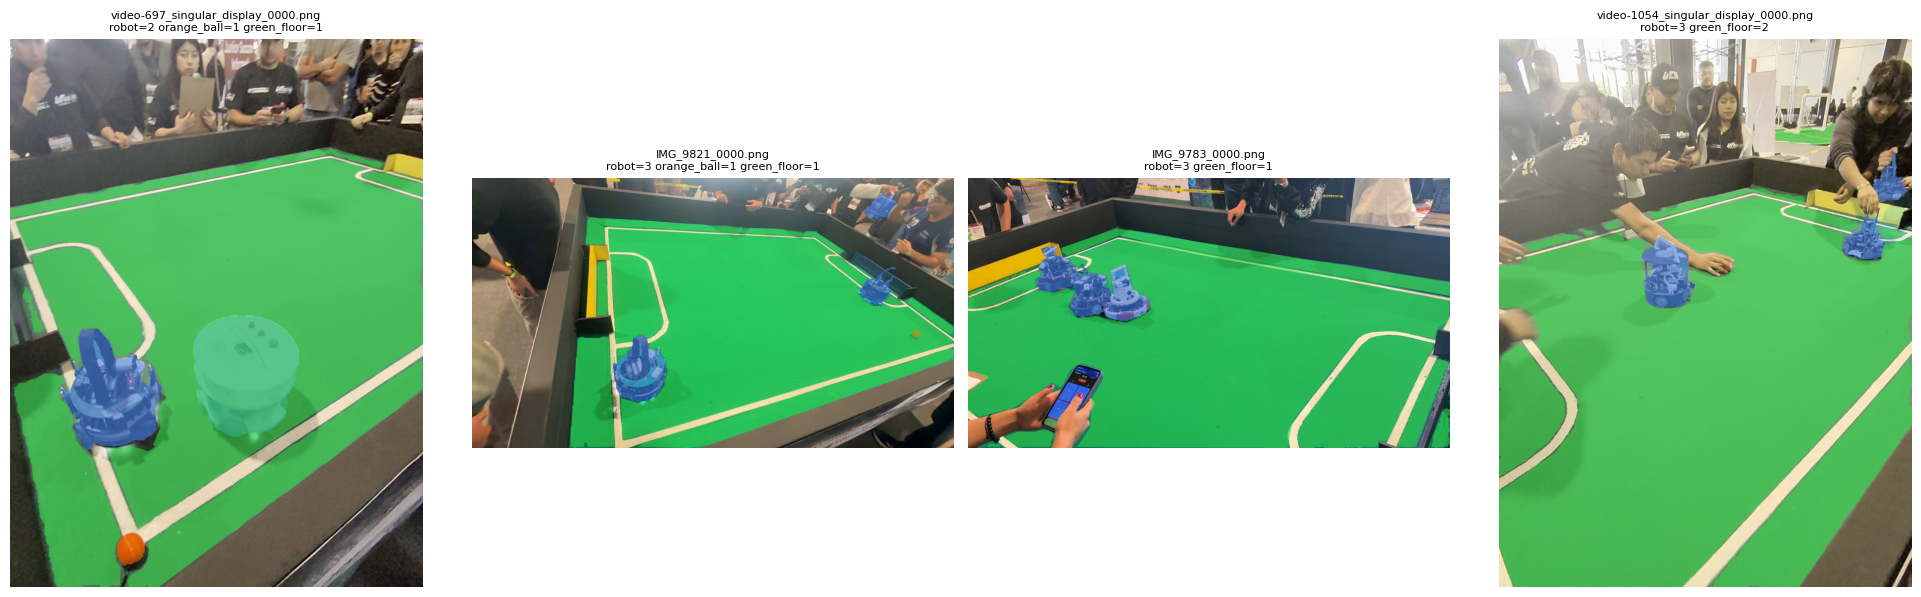

In [10]:
import random
random.seed(42)
sample_imgs = random.sample(coco['images'], min(4, len(coco['images'])))

color_by_cat = {c['coco_id']: np.array(c['color']) / 255.0 for c in CLASSES}
name_by_cat  = {c['coco_id']: c['name'] for c in CLASSES}

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
for ax, img_meta in zip(axes, sample_imgs):
    img = np.array(Image.open(IMAGES_DIR / img_meta['file_name'])).astype(np.float32) / 255.0
    H, W, _ = img.shape
    overlay = img.copy()
    anns = [a for a in coco['annotations'] if a['image_id'] == img_meta['id']]
    for ann in anns:
        cat_id = ann['category_id']
        color = color_by_cat[cat_id]
        # Reconstruir máscara desde polygons
        mask = np.zeros((H, W), dtype=np.uint8)
        for poly in ann['segmentation']:
            pts = np.array(poly, dtype=np.int32).reshape(-1, 2)
            cv2.fillPoly(mask, [pts], 1)
        m = mask.astype(bool)
        overlay[m] = 0.45 * overlay[m] + 0.55 * color
    ax.imshow(overlay)
    counts = Counter(a['category_id'] for a in anns)
    legend = ' '.join(f'{name_by_cat[k]}={v}' for k, v in counts.items())
    ax.set_title(f'{img_meta["file_name"]}\n{legend}', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 11. Upload a Roboflow (opcional)

**Requisitos antes de poner `ROBOFLOW_UPLOAD = True`:**
1. Tener `ROBOFLOW_API_KEY` en `/workspace/.env` (ya hecho)
2. Crear proyecto en https://app.roboflow.com → New Project → **Instance Segmentation**
3. Anotar el project ID en el celda 1 (constante `ROBOFLOW_PROJECT`)

Cada imagen + sus anotaciones COCO se suben por separado (formato esperado por Roboflow SDK).

In [11]:
if not ROBOFLOW_UPLOAD:
    print('ROBOFLOW_UPLOAD=False — skipping upload. Cambia a True en celda 1 cuando tengas el project ID.')
else:
    from roboflow import Roboflow
    rf = Roboflow(api_key=os.environ['ROBOFLOW_API_KEY'])
    project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
    print(f'Project: {project.name}')

    BATCH = f'sam3_auto_{DATASET_VERSION}'
    failed = []
    success = 0

    for img_meta in tqdm(coco['images'], desc='Upload'):
        anns = [a for a in coco['annotations'] if a['image_id'] == img_meta['id']]
        if not anns:
            continue
        # Mini-COCO con SOLO esta imagen + sus anotaciones (formato Roboflow per-image)
        per_img_coco = {
            'info': coco['info'],
            'categories': coco['categories'],
            'images': [img_meta],
            'annotations': anns,
        }
        per_img_json = DATASET_DIR / 'per_image_tmp.json'
        with open(per_img_json, 'w') as f:
            json.dump(per_img_coco, f)
        try:
            project.upload(
                image_path=str(IMAGES_DIR / img_meta['file_name']),
                annotation_path=str(per_img_json),
                batch_name=BATCH,
                split='train',
                num_retry_uploads=2,
            )
            success += 1
        except Exception as e:
            failed.append((img_meta['file_name'], str(e)))
    per_img_json.unlink(missing_ok=True)
    print(f'\nSubidas OK: {success}/{len(coco["images"])}, fallaron: {len(failed)}')
    if failed[:3]:
        print('Primeros 3 errores:')
        for n, e in failed[:3]:
            print(f'  {n}: {e[:80]}')

loading Roboflow workspace...


loading Roboflow project...


Project: Segmentacion_FUTBOT


Upload:   0%|          | 0/100 [00:00<?, ?it/s]


Subidas OK: 100/100, fallaron: 0


## 12. Next steps

**Cuando termine este notebook con éxito:**
1. Revisar dataset en `outputs/coco_dataset_v1/` (imgs + annotations.json)
2. Si `ROBOFLOW_UPLOAD=True`: revisar el proyecto en Roboflow web — debería verse el batch `sam3_auto_v1`
3. **En Roboflow:** ir manualmente a corregir misdetections (los que SAM 3 zero-shot equivocó)
4. Generar version → fine-tune SAM 3 desde el blog de Roboflow

**Pa' escalar a 1000 frames:**
- Necesitas GPU pod 5090 (mismo volume montado → todo lo de este notebook funciona idéntico)
- Cambia `TARGET_FRAMES = 1000` en celda 1
- Re-corre Run All → ~25 min en 5090